# 04 — Actionable Insights & Recommendations

**Group D — Grid Load Prediction**

Turns the trained model (`03_model_training_eval`) into business insights: what drives grid load, when/where it peaks, where the model can and can't be trusted, and concrete recommendations. **Assignment Task 12** (conclusions, actionable insights, recommendations). Self-contained — all code is in the notebook.

In [1]:
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
REPO = Path.cwd()
while not (REPO / 'data').exists() and REPO != REPO.parent:
    REPO = REPO.parent
FIGS = REPO / 'reports' / 'figures'; FIGS.mkdir(parents=True, exist_ok=True)
PROC = REPO / 'data' / 'processed'
print('repo:', REPO)

repo: /home/winzer/code/python/class/aion-gridload


## 1. Recap — the model we are interpreting
GradientBoosting was selected in notebook 03. Load the saved model, engineered data and its metrics.

In [2]:
import joblib
df = pd.read_csv(PROC / 'grid_load_features.csv')
clean = pd.read_csv(PROC / 'grid_load_clean.csv')       # has raw Region text + Hour for grouping
TARGET = 'GridLoad_MW'
X = df.drop(columns=[TARGET]); y = df[TARGET]
model = joblib.load(REPO / 'best_model' / 'best_model.joblib')
metrics = pd.read_csv(REPO / 'best_model' / 'metrics.csv', index_col=0).iloc[:,0]
print('Model :', metrics['model'])
print('Test  : RMSE %.2f | R2 %.3f | MAPE %.2f%%' % (float(metrics['RMSE']), float(metrics['R2']), float(metrics['MAPE%'])))
print('Load range: %.0f - %.0f MW (mean %.0f)' % (y.min(), y.max(), y.mean()))

Model : GradientBoosting
Test  : RMSE 13.96 | R2 0.982 | MAPE 1.88%
Load range: 370 - 900 MW (mean 616)


## 2. What drives grid load?
Two views: model **feature importance** (impurity + permutation) and raw **correlation** with load.

In [3]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
imp_impurity = pd.Series(model.feature_importances_, index=X.columns)
perm = permutation_importance(model, Xte, yte, n_repeats=15, random_state=42, n_jobs=-1)
imp_perm = pd.Series(perm.importances_mean, index=X.columns)
drivers = pd.DataFrame({'impurity': imp_impurity, 'permutation': imp_perm}).sort_values('impurity', ascending=False)
drivers.round(4).head(8)

,impurity,permutation
IndustrialIndex,0.7486,1.4043
PopulationIndex,0.1849,0.3482
Region_Encoded,0.0245,0.0479
Hour,0.0151,0.0286
Temperature_C,0.0110,0.0162
Humidity_pct,0.0047,0.0084
Rainfall_mm,0.0043,0.0038
Evening_Peak,0.0041,0.0021


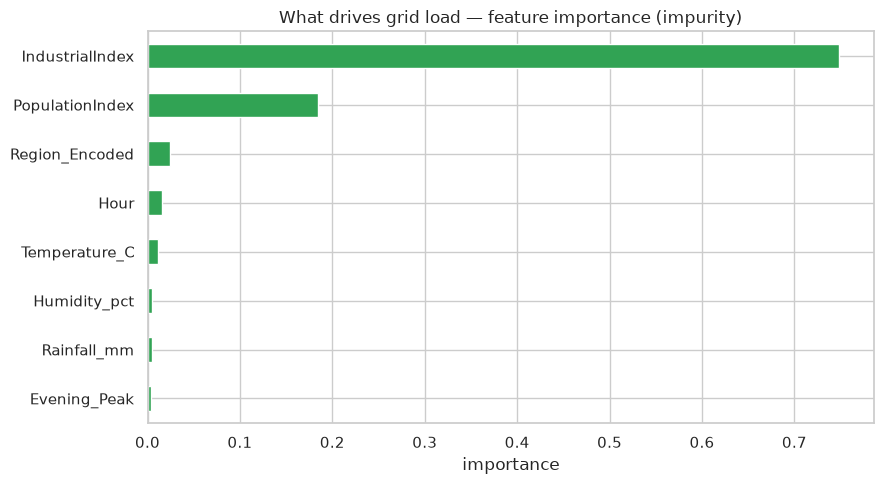

IndustrialIndex + PopulationIndex account for 93% of model importance.


In [4]:
top = drivers.sort_values('impurity').tail(8)
fig, ax = plt.subplots(figsize=(9,5))
top['impurity'].plot.barh(ax=ax, color='#31a354')
ax.set_title('What drives grid load — feature importance (impurity)'); ax.set_xlabel('importance')
fig.tight_layout(); fig.savefig(FIGS/'04_load_drivers.png', dpi=120); plt.show()
share = drivers['impurity'].nlargest(2).sum()
print('IndustrialIndex + PopulationIndex account for %.0f%% of model importance.' % (share*100))

**Insight:** industrial and population activity dominate; weather and calendar flags are minor. The grid load is driven by *who and what is drawing power*, far more than by the weather.

## 3. When and where does load peak?
Group the cleaned data by hour, region and weekday/weekend.

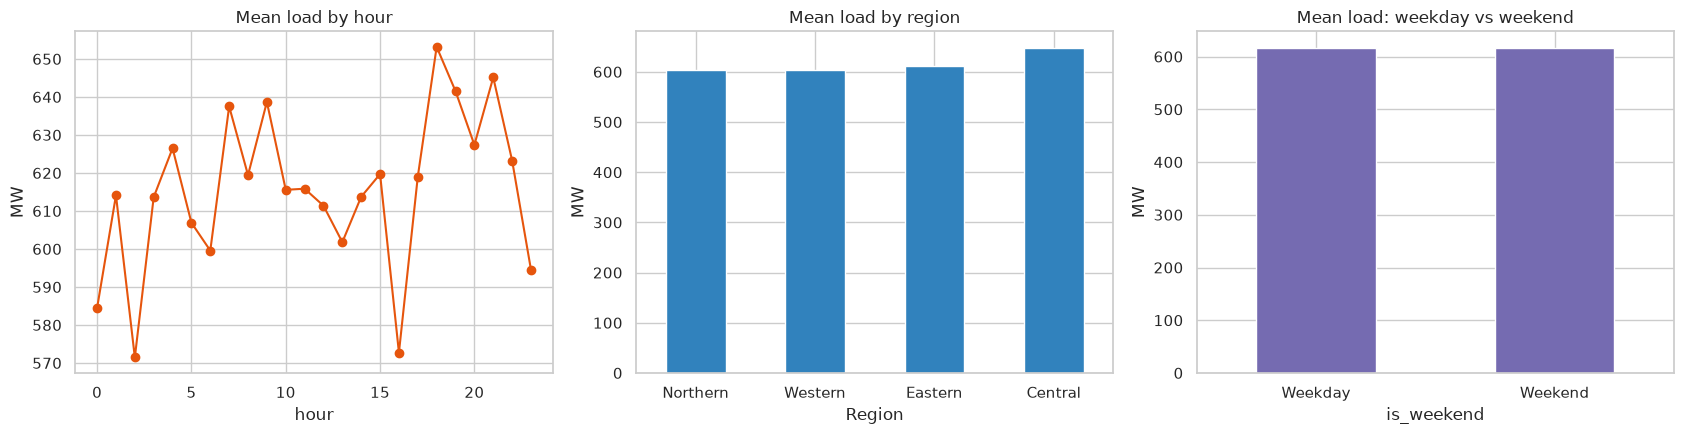

In [5]:
clean['is_weekend'] = np.where(clean['DayOfWeek']>=5, 'Weekend', 'Weekday')
fig, ax = plt.subplots(1, 3, figsize=(17,4.5))
clean.groupby('Hour')[TARGET].mean().plot(marker='o', ax=ax[0], color='#e6550d')
ax[0].set_title('Mean load by hour'); ax[0].set_xlabel('hour'); ax[0].set_ylabel('MW')
clean.groupby('Region')[TARGET].mean().sort_values().plot.bar(ax=ax[1], color='#3182bd')
ax[1].set_title('Mean load by region'); ax[1].set_ylabel('MW'); ax[1].tick_params(axis='x', rotation=0)
clean.groupby('is_weekend')[TARGET].mean().plot.bar(ax=ax[2], color='#756bb1')
ax[2].set_title('Mean load: weekday vs weekend'); ax[2].set_ylabel('MW'); ax[2].tick_params(axis='x', rotation=0)
fig.tight_layout(); fig.savefig(FIGS/'04_when_where_peaks.png', dpi=120); plt.show()

## 3b. Hourly load — weekend vs weekday
The bars above compare *overall* weekday/weekend averages. This overlays the **full daily curve** for each, showing not just whether weekends are lower, but *at which hours* the two diverge.

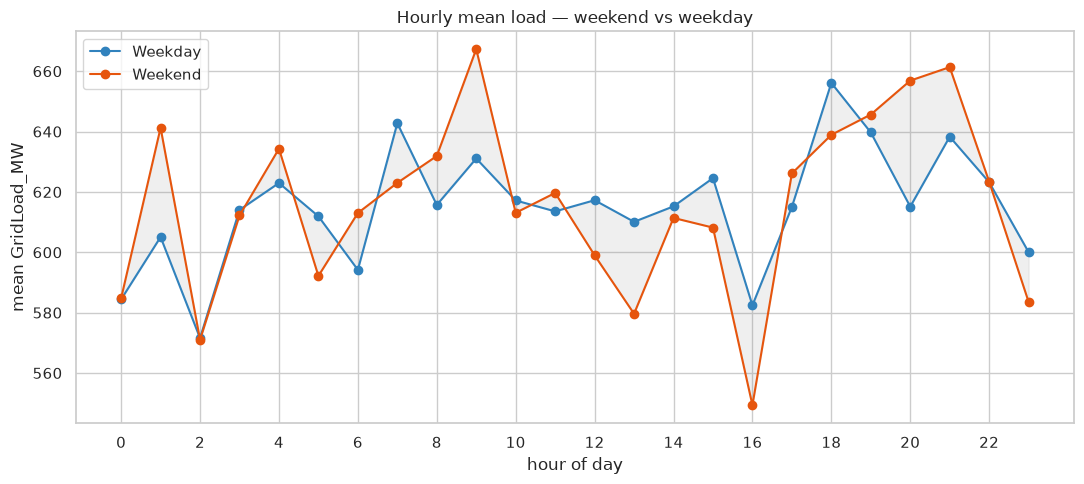

Mean load  — weekday: 615.1 MW | weekend: 616.1 MW
Largest weekday-minus-weekend gap at hour 16: 33.1 MW


In [6]:
# mean load at each hour, split by weekend vs weekday
hourly = clean.groupby(['is_weekend', 'Hour'])[TARGET].mean().unstack('is_weekend')

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(hourly.index, hourly['Weekday'], marker='o', label='Weekday', color='#3182bd')
ax.plot(hourly.index, hourly['Weekend'], marker='o', label='Weekend', color='#e6550d')
ax.fill_between(hourly.index, hourly['Weekday'], hourly['Weekend'], alpha=0.12, color='grey')
ax.set_xlabel('hour of day'); ax.set_ylabel('mean GridLoad_MW'); ax.set_xticks(range(0, 24, 2))
ax.set_title('Hourly mean load — weekend vs weekday'); ax.legend()
fig.tight_layout(); fig.savefig(FIGS/'04_hourly_weekend_vs_weekday.png', dpi=120); plt.show()

# quantify the gap
gap = hourly['Weekday'] - hourly['Weekend']
print('Mean load  — weekday: %.1f MW | weekend: %.1f MW' % (hourly['Weekday'].mean(), hourly['Weekend'].mean()))
print('Largest weekday-minus-weekend gap at hour %d: %.1f MW' % (gap.idxmax(), gap.max()))

## 4. Where does the model make mistakes?
Break test-set absolute error down by region and hour — shows *when to trust it less*.

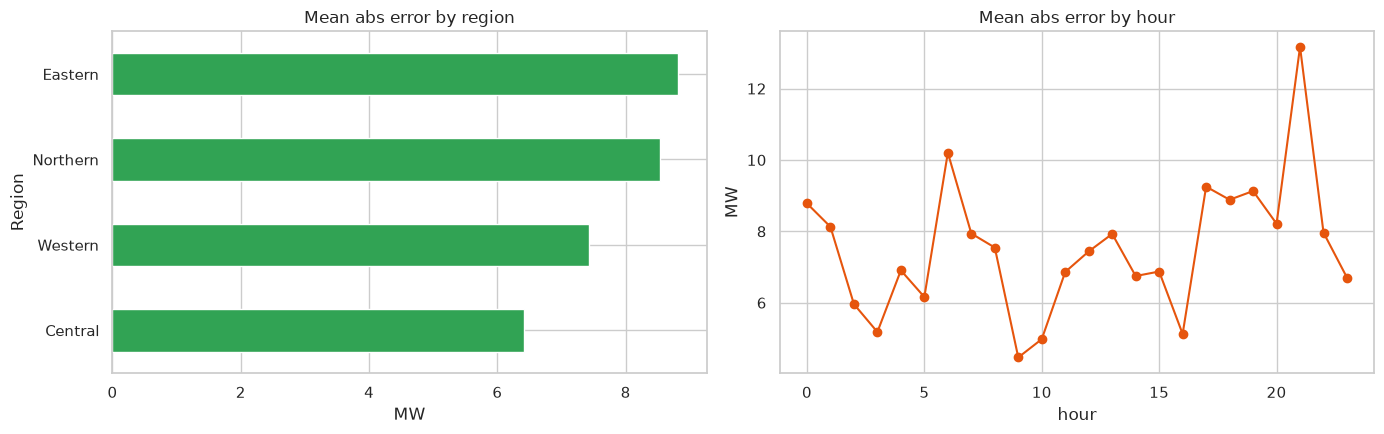

Worst region: Eastern | worst hours: [21.0, 6.0, 17.0]


In [7]:
err = clean.loc[yte.index].copy()
err['abs_err'] = np.abs(yte.values - model.predict(Xte))
fig, ax = plt.subplots(1, 2, figsize=(14,4.5))
err.groupby('Region')['abs_err'].mean().sort_values().plot.barh(ax=ax[0], color='#31a354')
ax[0].set_title('Mean abs error by region'); ax[0].set_xlabel('MW')
err.groupby('Hour')['abs_err'].mean().plot(marker='o', ax=ax[1], color='#e6550d')
ax[1].set_title('Mean abs error by hour'); ax[1].set_xlabel('hour'); ax[1].set_ylabel('MW')
fig.tight_layout(); fig.savefig(FIGS/'04_error_breakdown.png', dpi=120); plt.show()
print('Worst region: %s | worst hours: %s' % (
    err.groupby('Region')['abs_err'].mean().idxmax(),
    list(err.groupby('Hour')['abs_err'].mean().nlargest(3).index)))

## 5. Sensitivity — how load responds to its top drivers
Sweep IndustrialIndex and PopulationIndex across their ranges (holding other features at their median) and read the model's predicted load. This quantifies the levers for planning.

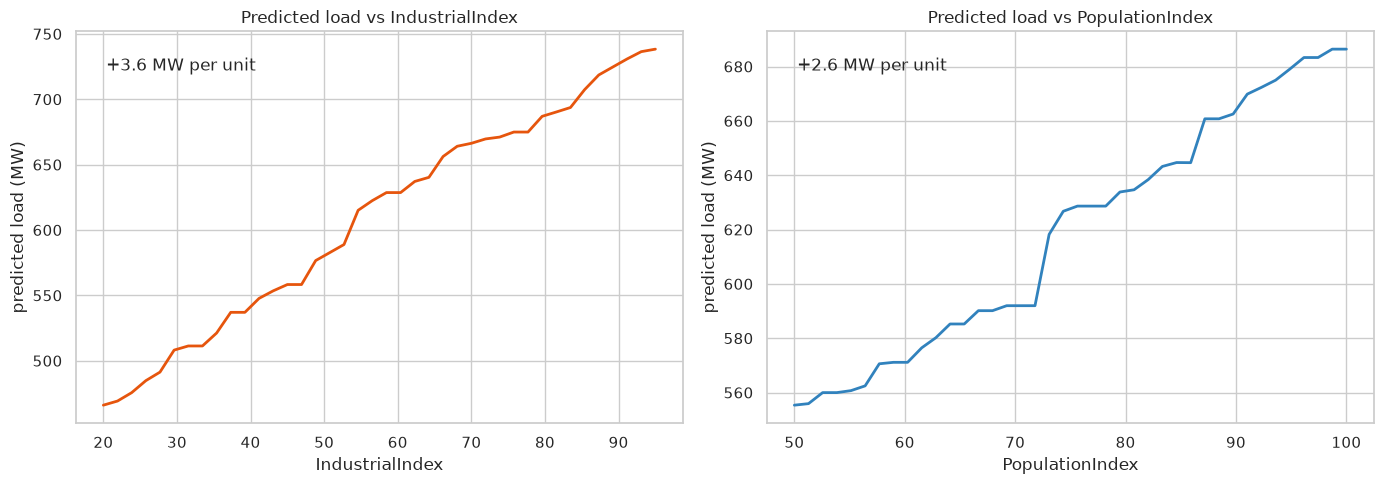

In [8]:
def sweep(feature, n=40):
    base = X.median(numeric_only=True)                 # hold everything at median
    grid = np.linspace(X[feature].min(), X[feature].max(), n)
    rows = pd.DataFrame([base]*n).reset_index(drop=True)
    rows[feature] = grid
    return grid, model.predict(rows[X.columns])

fig, ax = plt.subplots(1, 2, figsize=(14,5))
for a, feat, col in zip(ax, ['IndustrialIndex','PopulationIndex'], ['#e6550d','#3182bd']):
    g, p = sweep(feat)
    a.plot(g, p, color=col, lw=2); a.set_xlabel(feat); a.set_ylabel('predicted load (MW)')
    a.set_title(f'Predicted load vs {feat}')
    slope = (p[-1]-p[0])/(g[-1]-g[0])
    a.annotate(f'+{slope:.1f} MW per unit', xy=(0.05,0.9), xycoords='axes fraction')
fig.tight_layout(); fig.savefig(FIGS/'04_sensitivity.png', dpi=120); plt.show()

**Insight:** predicted load rises steadily with both indices — the plots give a concrete 'MW per unit of activity' figure to feed capacity planning.

## 6. Actionable recommendations
1. **Protect the top inputs.** ~93% of predictive power sits in IndustrialIndex + PopulationIndex — invest in collecting these accurately and on time; the model degrades most when they are stale or missing.
2. **Plan capacity around the evening peak and the highest-load region** (see §3) — that is where headroom matters most.
3. **Do not over-invest in weather data feeds.** Temperature/humidity/rainfall are minor predictors here; effort is better spent on activity indices.
4. **Validate data at entry.** The raw data had impossible values (Hour=30, negative humidity) and junk tokens; input validation stops these from reaching the model.
5. **Watch the high-error segments** flagged in §4 — apply a wider safety margin there.
6. **Refresh the model** when the activity indices' distribution shifts (new industry, population growth).

## 7. Limitations
- Data is **cross-sectional** (no continuous timestamp) → this predicts load from conditions, it is not a time-series forecaster. Lag/rolling features would need a real time index.
- Dataset is small (~1.5k rows); estimates carry the CV variance reported in notebook 03.
- Region is label-encoded as an ordinal; one-hot could be explored if a linear model were used.

## Summary
- ✅ **Task 12** — conclusions, insights and recommendations delivered from the model results.
- Figures saved to `reports/figures/04_*.png`.
- Headline: grid load is driven by industrial + population activity; plan around evening peaks and the top region; keep those two inputs clean and current.